In [8]:
import pandas as pd
import numpy as np
import scipy.io as sio
import torch
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

In [9]:

phase1_data = sio.loadmat('../data/mine_impact_data_2019.mat')
samples  = pd.DataFrame(phase1_data["x"].T)
labels  = pd.DataFrame(phase1_data["y"].T, columns=["y"])

df = pd.concat([samples, labels], axis=1, join="inner")

df = df.dropna()

shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

## To create this new axis and reduce dimensionality, LDA follows these criteria:

## Maximize the distance between the means of two classes.
## Minimize the variance within individual classes.


In [12]:

scaler = StandardScaler()
scaler.fit(df_X)
X = scaler.transform(df_X)


X_train = X[:3000]
X_test = X[3000:]

Y_train = df_Y.iloc[:3000].values
Y_test = df_Y.iloc[3000:].values

# lda finds linear combinations of features that best separate two or more classes.

#The statistical properties that are estimated from the data set are fed into the LDA function to make predictions and create the LDA model. 
# There are some constraints to bear in mind, as the model assumes the following:

# The input dataset has a Gaussian distribution, where plotting the data points gives a bell-shaped curve.
# The data set is linearly separable, meaning LDA can draw a straight line or a decision boundary that separates the data points.
# Each class has the same covariance matrix.
# For these reasons, LDA may not perform well in high-dimensional feature spaces.
lda = LinearDiscriminantAnalysis(n_components=1)

lda.fit(X_train, Y_train)

y_pred = lda.predict(X_test)


              precision    recall  f1-score   support

           0       0.82      0.77      0.79       215
           1       0.53      0.61      0.57        94

    accuracy                           0.72       309
   macro avg       0.67      0.69      0.68       309
weighted avg       0.73      0.72      0.72       309

Accuracy: 0.7184466019417476


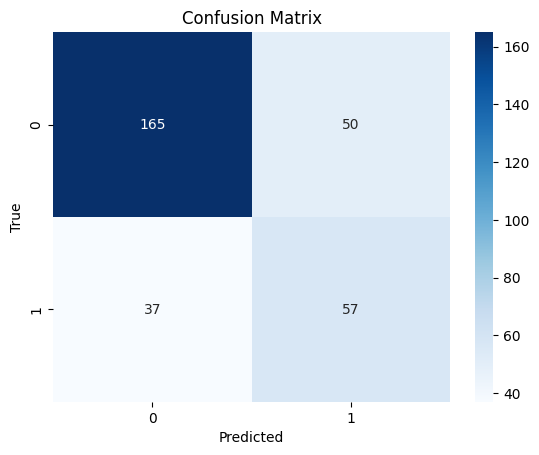

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(Y_test, y_pred))
print("Accuracy:", accuracy_score(Y_test, y_pred))
cm = confusion_matrix(Y_test, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(Y_test), yticklabels=np.unique(Y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# we aim to maximize recall for class 0

In [14]:
#pca_lda

from data_classes.decomposition import PCA_features

data = PCA_features(df_X, df_Y, n_components=2)

In [15]:
pca_lda = LinearDiscriminantAnalysis(n_components=1)

lda.fit(data.get_samples()[:3000],data.get_labels()[:3000])

y_pred = lda.predict(data.get_samples()[3000:])
print("Accuracy:", accuracy_score(data.get_labels()[3000:], y_pred))

Accuracy: 0.6925566343042071
